In [2]:
import torch
print(torch.__version__)

2.9.0+cpu


In [3]:
from sklearn.datasets import make_classification


In [4]:
x, y = make_classification(
    n_samples = 10,
    n_features = 2,
    n_informative = 2,
    n_redundant = 0,
    n_classes = 2,
    random_state = 42
)

In [5]:
x

array([[ 1.06833894, -0.97007347],
       [-1.14021544, -0.83879234],
       [-2.8953973 ,  1.97686236],
       [-0.72063436, -0.96059253],
       [-1.96287438, -0.99225135],
       [-0.9382051 , -0.54304815],
       [ 1.72725924, -1.18582677],
       [ 1.77736657,  1.51157598],
       [ 1.89969252,  0.83444483],
       [-0.58723065, -1.97171753]])

In [6]:
y

array([1, 0, 0, 0, 0, 1, 1, 1, 1, 0])

In [7]:
X = torch.tensor(x, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

In [8]:
from torch.utils.data import Dataset, DataLoader

In [9]:
class myDataset(Dataset):

    def __init__(self,features,labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return self.features.shape[0]
    
    def __getitem__(self,index):
        return self.features[index], self.labels[index]
    


In [10]:
dataset = myDataset(X,y)

In [11]:
dataloader = DataLoader(dataset, batch_size=2, shuffle=True)


In [12]:
for batch_features, batch_labels in dataloader:
    print(batch_features)
    print(batch_labels)
    print('_'*50)

tensor([[ 1.7774,  1.5116],
        [-1.1402, -0.8388]])
tensor([1, 0])
__________________________________________________
tensor([[-0.7206, -0.9606],
        [ 1.0683, -0.9701]])
tensor([0, 1])
__________________________________________________
tensor([[-1.9629, -0.9923],
        [-0.9382, -0.5430]])
tensor([0, 1])
__________________________________________________
tensor([[-2.8954,  1.9769],
        [-0.5872, -1.9717]])
tensor([0, 0])
__________________________________________________
tensor([[ 1.7273, -1.1858],
        [ 1.8997,  0.8344]])
tensor([1, 1])
__________________________________________________


## Improving the Existing Model with DataLoaders 

In [13]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import torch.nn as nn 

In [15]:
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')

In [16]:
df.drop(columns=['id', 'Unnamed: 32'],inplace=True)

In [17]:
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,1:],df.iloc[:,0],test_size=0.2)

In [18]:
scaler = StandardScaler()
 
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
encoder = LabelEncoder()

y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

In [20]:
X_train_tensor = torch.from_numpy(X_train)
X_test_tensor = torch.from_numpy(X_test)

y_train_tensor = torch.from_numpy(y_train)
y_test_tensor = torch.from_numpy(y_test)

X_train_tensor = X_train_tensor.float()
X_test_tensor = X_test_tensor.float()

y_train_tensor = y_train_tensor.float()
y_test_tensor = y_test_tensor.float()


In [21]:
learning_rate = 0.1
epochs = 35

In [22]:
class mySimpleModel(nn.Module):
    
    def __init__(self,num_features):

        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(num_features,1),
            nn.Sigmoid()
        )
        self.loss_fn = nn.BCELoss()
        self.optimizer = torch.optim.SGD(self.parameters(),lr=learning_rate)

    def forward(self,feature):
        return self.network(feature)

    def loss_function(self,y_pred,y):
        return self.loss_fn(y_pred,y)



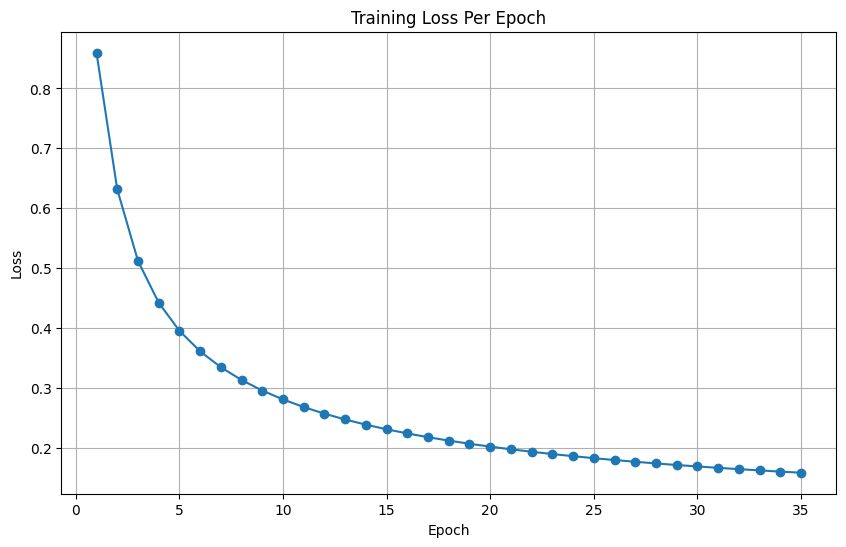

In [23]:
model = mySimpleModel(X_train_tensor.shape[1])
losses = []


for epoch in range(epochs):
    # forward
    y_pred = model(X_train_tensor)

    loss = model.loss_function(y_pred,y_train_tensor.view(-1,1))

    # clear gradients  
    model.optimizer.zero_grad()
    # backward 
    loss.backward()

    # parameters update 

    model.optimizer.step()
    losses.append(loss.item())

    # print(f"Epoch : {epoch+1}, loss : {loss.item()}")
    
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(range(1,epochs+1),losses,marker='o')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training Loss Per Epoch")
ax.grid(True)
plt.show()


In [24]:
with torch.no_grad():
    y_pred = model.forward(X_test_tensor)
    y_pred = (y_pred > 0.8).float()
    accuracy = (y_pred == y_test_tensor).float().mean()
    print(f"Accuracy : {accuracy}")

Accuracy : 0.5338565707206726


In [25]:
class customDataset(Dataset):

    def __init__(self, features, labels):
        self.features = features
        self.labels = labels

    def __len__(self):
        return self.features.shape[0]  

    def __getitem__(self, index):
        return self.features[index], self.labels[index]
      

In [26]:
train_dataset = customDataset(X_train_tensor,y_train_tensor)
test_dataset = customDataset(X_test_tensor,y_test_tensor)

In [27]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [28]:
class mySimpleModel(nn.Module):
    
    def __init__(self,num_features):

        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(num_features,1),
            nn.Sigmoid()
        )
        self.loss_fn = nn.BCELoss()
        self.optimizer = torch.optim.SGD(self.parameters(),lr=learning_rate)

    def forward(self,feature):
        return self.network(feature)

    def loss_function(self,y_pred,y):
        return self.loss_fn(y_pred,y)


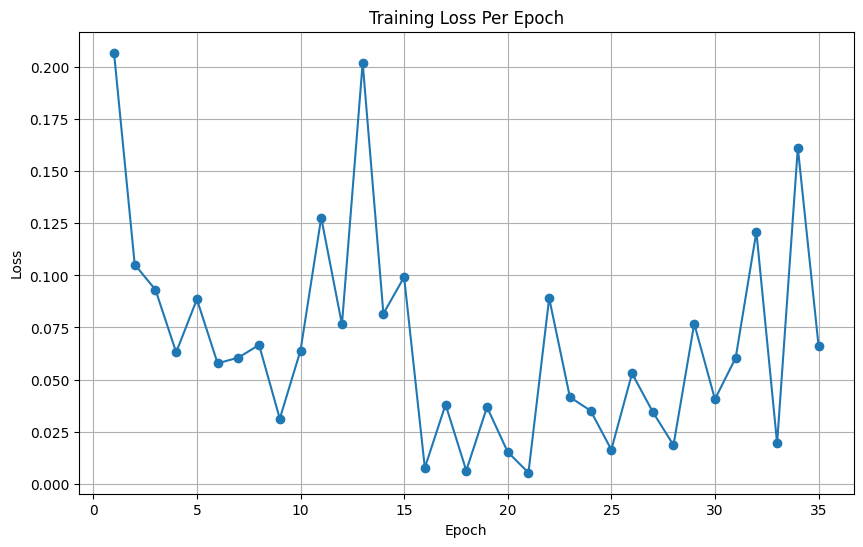

In [29]:
model = mySimpleModel(X_train_tensor.shape[1])
losses = []


for epoch in range(epochs):

    for batch_features, batch_labels in train_loader:

        # forward
        y_pred = model(batch_features)

        loss = model.loss_function(y_pred,batch_labels.view(-1,1))

        # clear gradients  
        model.optimizer.zero_grad()
        # backward 
        loss.backward()

        # parameters update 

        model.optimizer.step()
        
    losses.append(loss.item())

        # print(f"Epoch : {epoch+1}, loss : {loss.item()}")
    
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(range(1,epochs+1),losses,marker='o')
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training Loss Per Epoch")
ax.grid(True)
plt.show()


## Evaluation

Accuracy : 0.9705


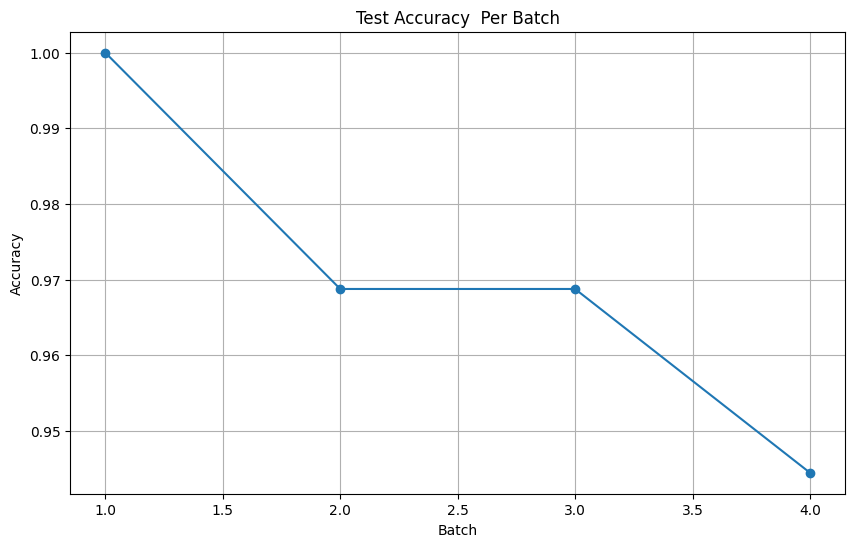

In [30]:
model.eval()
accuracy_list = []

with torch.no_grad():
    for batch_features, batch_labels in test_loader:

        y_pred = model(batch_features)
        y_pred = (y_pred >0.5 ).float()

        batch_accuracy = (y_pred.view(-1) == batch_labels).float().mean().item()
        accuracy_list.append(batch_accuracy)

overall_accuracy = sum(accuracy_list)/len(accuracy_list)
print(f"Accuracy :{overall_accuracy: .4f}") 


fig, ax = plt.subplots(figsize=(10,6))
ax.plot(range(1,len(accuracy_list)+1),accuracy_list,marker='o')
ax.set_xlabel("Batch")
ax.set_ylabel("Accuracy")
ax.set_title("Test Accuracy  Per Batch")
ax.grid(True)
plt.show()